This workbook implements a form of generalised profiling: Chemical reaction network mode with synthetic data.

Matthew J Simpson - QUT

Ruth E Baker - Oxford

December 2025

In [99]:
using Plots, DifferentialEquations, Random, Distributions, NLopt, Dierckx, LaTeXStrings, BSplineKit, Statistics
using SparseArrays, StatsAPI, LinearAlgebra
gr(); #Load packages 

In [100]:
Tend = 100;
t=LinRange(0,Tend,11);    #Discretised time variable, coarse discretisation for data
tf=LinRange(0,Tend,1001); #Discretised time variable, fine discretisation for ODE enforcing
r1t = 0.06; r2t = 0.04; C10t=100.0; C20t=0.0; σt = 0.10
C1e(t) = C10t*exp(-r1t*t);
C2e(t) = C10t*exp(-r1t*t)*r1t/(r2t-r1t)+(C20t-r1t*C10t/(r2t-r1t))*exp(-r2t*t); #Exact Solution
#data0 = zeros(2,length(t));
data = zeros(2,length(t));
#data0[1,:] = C1e.(t)
#data0[2,:] = C2e.(t)
#data[1,:]=data0[1,:].*exp.(σt*randn(length(t)));
#data[2,:]=data0[2,:].*exp.(σt*randn(length(t)));

In [101]:
data[1,:] = [ 96.56096784939415
 53.162683263898955
 30.21353526110562
 15.611442927441265
 10.677454919299821
  4.7137710401556
  2.253702171011828
  1.3189952483476257
  0.8763526449923396
  0.41305784035161397
  0.2625630241082357]; #Data for chemical species 1

data[2,:]=[  0.0
 35.942343515405064
 42.91157908622552
 42.53476493106186
 25.976468794003566
 28.36374889889675
 16.460945063714938
 12.68232542619021
  9.396159570814048
  6.655427557473664
  4.410219138819559]; #Data for chemical species 2

In [103]:
S1_interp = interpolate(t, data[1,:], BSplineOrder(4)) #Create spline to overfit the data for species 1
B1 = basis(S1_interp);                                 #Basis functions for species 1
Coeff1 = coefficients(S1_interp)                       #Spline coefficients for species 1

C1_sp   = collocation_matrix(B1, t, Derivative(0), SparseMatrixCSC{Float64, Int});  #Collocation matrix for the first function on the coarse grid
C1_spf  = collocation_matrix(B1, tf, Derivative(0), SparseMatrixCSC{Float64, Int}); #Collocation matrix for the first function on the fine grid
C1_1spf = collocation_matrix(B1, tf, Derivative(1), SparseMatrixCSC{Float64, Int}); #Collocation matrix for the first derivative of the first function on the fine grid

C1   = C1_sp*Coeff1;   #Evaluate spline for the first function on the coarse grid
C1f  = C1_spf*Coeff1;  #Evaluate spline for the first function on the fine grid
dC1f = C1_1spf*Coeff1; #Evaluate spline for the first derivative of the first function on the fine grid


S2_interp = interpolate(t, data[2,:], BSplineOrder(4))  #Create spline to overfit the data for species 2
B2 = basis(S2_interp);                                  #Basis functions for species 2
Coeff2 = coefficients(S2_interp)                        #Spline coefficients for species 2

C2_sp   = collocation_matrix(B2, t, Derivative(0), SparseMatrixCSC{Float64, Int});   #Collocation matrix for the second function on the coarse grid
C2_spf  = collocation_matrix(B2, tf, Derivative(0), SparseMatrixCSC{Float64, Int});  #Collocation matrix for the second function on the fine grid
C2_1spf = collocation_matrix(B2, tf, Derivative(1), SparseMatrixCSC{Float64, Int});  #Collocation matrix for the first derivative of the second function on the fine grid

C2   = C2_sp*Coeff2;  #Evaluate spline for the second function on the coarse grid
C2f  = C2_spf*Coeff2  #Evaluate spline for the second function on the fine grid
dC2f = C2_1spf*Coeff2 #Evaluate spline for the first derivative of the second function on the fine grid

p1 = plot(tf,C1f,lw=4,lc=:red,label=false) #Plot results
p1 = plot!(tf,C2f,lw=4,lc=:aqua,label=false)
p1=scatter!(t,data[1,:],mc=:blue,msc=:blue,ms=5,label=false)
p1=scatter!(t,data[2,:],marker=:square,mc=:blue,msc=:blue,ms=5,label=false)
p1=plot!(xlabel=L"t",ylabel=L"C_1^{\textrm{o}}(t) \quad C_2^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
savefig("f5a.svg")

"C:\\Users\\simpsom3\\Dropbox\\Generalised Profiling\\Notebooks\\f5a.svg"

In [104]:
function loglhood(data,C1,C1f,dC1f,C2,C2f,dC2f,t,tf,w,a) #Function to evaluate the loglikelihood of the data stored in the vector data. 

ℓ =0; ℓd =0; ℓm =0;    
data_dists1=[LogNormal(0,a[3]) for _ in C1];
data_dists2=[LogNormal(0,a[3]) for _ in C2];

ℓd += sum(
    loglikelihood(data_dists1[i], data[1,i] / C1[i])
    for i in 1:length(data_dists1)
    if data[1,i] > 0 && C1[i] > 0
)  

ℓd+= sum(
    loglikelihood(data_dists2[i], data[2,i] / C2[i])
    for i in 1:length(data_dists2)
    if data[2,i] > 0 && C2[i] > 0
)
    
ℓm = sum((dC1f.+ a[1].*C1f).^2)/ length(tf) + sum((dC2f .- a[1].*C1f .+a[2].*C2f).^2)/ length(tf) 
ℓ = w[1]*ℓd - w[2]*ℓm;
return  ℓ

end;

In [105]:
function Optimise(fun,θ₀,lb,ub) # Optimize finds the values of parameters \theta that maximise the objective function fun with lower bounds lb, and upper bounds ub
    tomax=(θ,∂θ)->fun(θ)
    opt=Opt(:LN_NELDERMEAD,length(θ₀))
    opt.max_objective=tomax
    opt.lower_bounds=lb      
    opt.upper_bounds=ub
    opt.maxtime=1*60
    res = optimize(opt,θ₀)
    return res[[2,1]]
end

Optimise (generic function with 1 method)

In [106]:
r1min=0.0; r1max=1.0; r2min=0.0; r2max=1.0; σmin=0.01; σmax = 5.0; #Upper/Lower bounds
θG=[r1t, r2t, σt] #Iniitial estimate of the parameter values
lb=[r1min,r2min, σmin]
ub=[r1max,r2max, σmax]
a = zeros(3);
w = [1,1];
funopt(a) = loglhood(data,C1,C1f,dC1f,C2,C2f,dC2f,t,tf,w,a) 
(θ1,fopt)=Optimise(funopt,θG,lb,ub) #Call to NLopt 
a1 =  plot(tf,dC1f .+ θ1[1].*C1f,lw=4,color=:red,legend=false)
a1 = plot!(tf,dC2f .- θ1[1].*C1f.+ θ1[2].*C2f, lw=4,color=:aqua,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi_1(t) \quad \xi_2(t)",color=:red,xlims=(t[1]-5,t[end]+5),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14,ylims=[-2,2],yticks = ([-2, 0, 2],[L"-2", L"0", L"2"]))
savefig("f5b.svg")

"C:\\Users\\simpsom3\\Dropbox\\Generalised Profiling\\Notebooks\\f5b.svg"

Iteration 2

In [107]:
ℓd=0
data_dists1=[LogNormal(0,θ1[3]) for _ in t];
data_dists2=[LogNormal(0,θ1[3]) for _ in t];

ℓd += sum(
    loglikelihood(data_dists1[i], data[1,i] / C1[i])
    for i in 1:length(data_dists1)
    if data[1,i] > 0 && C1[i] > 0
)  

ℓd+= sum(
    loglikelihood(data_dists2[i], data[2,i] /  C2[i])
    for i in 1:length(data_dists2)
    if data[2,i] > 0 && C2[i] > 0
)


ℓm =0;
ℓm = sum((dC1f.+ θ1[1].*C1f).^2)/ length(tf) + sum((dC2f .- θ1[1].*C1f .+θ1[2].*C2f).^2)/ length(tf) ;

w = [1.0,abs(1/ℓm)];
funopt2(a) = loglhood(data,C1,C1f,dC1f,C2,C2f,dC2f,t,tf,w,a) #Here setting the weight to one
(θ2,fopt)=Optimise(funopt2,θG,lb,ub) #Call to NLopt 

([0.06050405614770056, 0.04146319200735299, 0.01], 76.4108647084518)

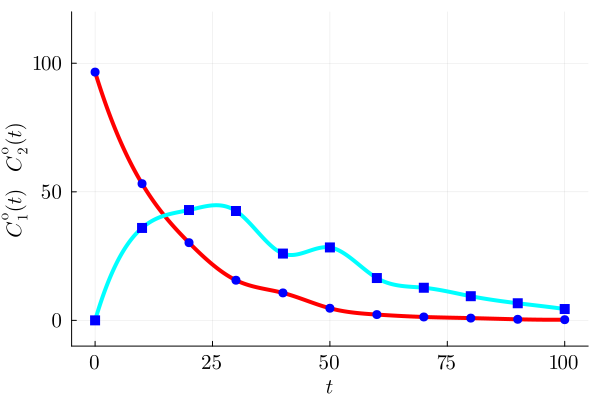

In [108]:
d2=zeros(length(tf)); d1=zeros(length(tf)); d0=zeros(length(t))

d0=data[1,:];
d1 = [-θ2[1]*C1f[i] for i in eachindex(tf)];
Coeff1 = vcat(w[1]*C1_sp,w[2]*C1_1spf) \ vcat(w[1]*d0,w[2]*d1);

d0=data[2,:];
d1 = [+θ2[1]*C1f[i]-θ2[2]*C2f[i] for i in eachindex(tf)];
Coeff2 = vcat(w[1]*C2_sp, w[2]*C2_1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,C1f,lw=4,lc=:red,label=false)
p4 = plot!(tf,C2f,lw=4,lc=:aqua,label=false)
p4=scatter!(t,data[1,:],mc=:blue,msc=:blue,ms=5,label=false)
p4=scatter!(t,data[2,:],mc=:blue,msc=:blue,ms=5,marker=:square,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C_1^{\textrm{o}}(t) \quad C_2^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

In [109]:
C1= C1_sp*Coeff1; C1f = C1_spf*Coeff1; dC1f = C1_1spf*Coeff1;
C2= C2_sp*Coeff2; C2f = C2_spf*Coeff2; dC2f = C2_1spf*Coeff2;

ℓd=0
data_dists1=[LogNormal(0,θ2[3]) for _ in t];
data_dists2=[LogNormal(0,θ2[3]) for _ in t];

ℓd += sum(
    loglikelihood(data_dists1[i], data[1,i] / C1[i])
    for i in 1:length(data_dists1)
    if data[1,i] > 0 && C1[i] > 0
)  

ℓd+= sum(
    loglikelihood(data_dists2[i], data[2,i] /  C2[i])
    for i in 1:length(data_dists2)
    if data[2,i] > 0 && C2[i] > 0
)

ℓm =0;
ℓm = sum((dC1f.+ θ2[1].*C1f).^2)/ length(tf) + sum((dC2f .- θ2[1].*C1f .+θ2[2].*C2f).^2)/ length(tf) 

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance -1495.306678019197
Model distance 0.01177925095911485


Iteration 3

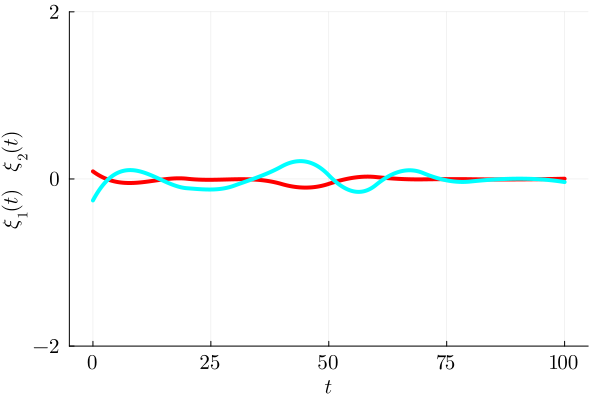

In [110]:
funopt3(a) = loglhood(data,C1,C1f,dC1f,C2,C2f,dC2f,t,tf,w,a) #Here setting the weight to one
(θ3,fopt)=Optimise(funopt3,θG,lb,ub) #Call to NLopt 

a1 =  plot(tf,dC1f .+ θ3[1].*C1f,lw=4,color=:red,legend=false)
a1 = plot!(tf,dC2f .- θ3[1].*C1f.+ θ3[2].*C2f, lw=4,color=:aqua,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi_1(t) \quad \xi_2(t)",color=:red,xlims=(t[1]-5,t[end]+5),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14,ylims=[-2,2],yticks = ([-2, 0, 2],[L"-2", L"0", L"2"]))

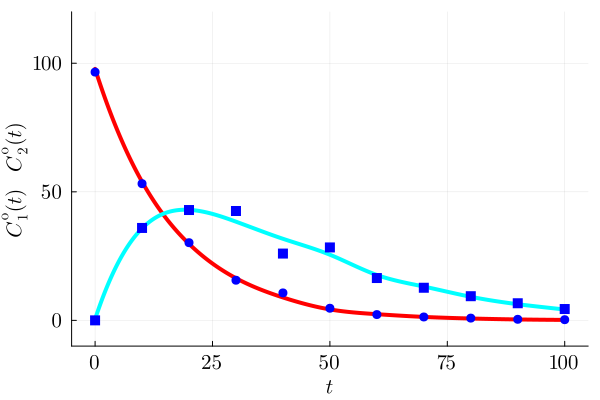

In [111]:
d0=data[1,:];
d1 = [-θ3[1]*C1f[i] for i in eachindex(tf)];
Coeff1 = vcat(w[1]*C1_sp,w[2]*C1_1spf) \ vcat(w[1]*d0,w[2]*d1);

d0=data[2,:];
d1 = [+θ3[1]*C1f[i]-θ3[2]*C2f[i] for i in eachindex(tf)];
Coeff2 = vcat(w[1]*C2_sp, w[2]*C2_1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,C1f,lw=4,lc=:red,label=false)
p4 = plot!(tf,C2f,lw=4,lc=:aqua,label=false)
p4=scatter!(t,data[1,:],mc=:blue,msc=:blue,ms=5,label=false)
p4=scatter!(t,data[2,:],mc=:blue,msc=:blue,ms=5,marker=:square,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C_1^{\textrm{o}}(t) \quad C_2^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

In [112]:
C1= C1_sp*Coeff1; C1f = C1_spf*Coeff1; dC1f = C1_1spf*Coeff1;
C2= C2_sp*Coeff2; C2f = C2_spf*Coeff2; dC2f = C2_1spf*Coeff2;

ℓd=0
data_dists1=[LogNormal(0,θ3[3]) for _ in t];
data_dists2=[LogNormal(0,θ3[3]) for _ in t];

ℓd += sum(
    loglikelihood(data_dists1[i], data[1,i] / C1[i])
    for i in 1:length(data_dists1)
    if data[1,i] > 0 && C1[i] > 0
)  

ℓd+= sum(
    loglikelihood(data_dists2[i], data[2,i] /  C2[i])
    for i in 1:length(data_dists2)
    if data[2,i] > 0 && C2[i] > 0
)

ℓm =0;
ℓm = sum((dC1f.+ θ3[1].*C1f).^2)/ length(tf) + sum((dC2f .- θ3[1].*C1f .+θ3[2].*C2f).^2)/ length(tf) 

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance -45.52146198343842
Model distance 0.004556204924203782


Iteration 4

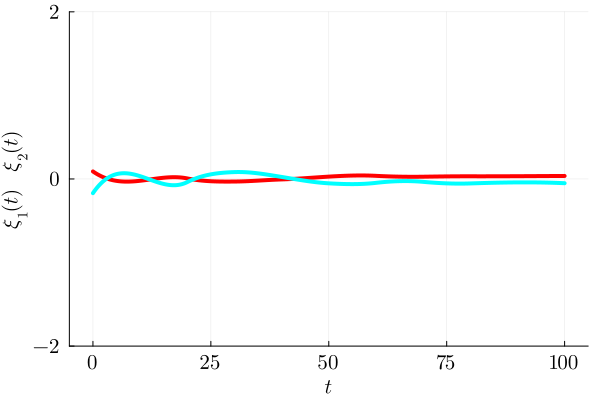

In [113]:
funopt4(a) = loglhood(data,C1,C1f,dC1f,C2,C2f,dC2f,t,tf,w,a) #Here setting the weight to one
(θ4,fopt)=Optimise(funopt4,θG,lb,ub) #Call to NLopt 

a1 =  plot(tf,dC1f .+ θ4[1].*C1f,lw=4,color=:red,legend=false)
a1 = plot!(tf,dC2f .- θ4[1].*C1f.+ θ4[2].*C2f, lw=4,color=:aqua,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi_1(t) \quad \xi_2(t)",color=:red,xlims=(t[1]-5,t[end]+5),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14,ylims=[-2,2],yticks = ([-2, 0, 2],[L"-2", L"0", L"2"]))

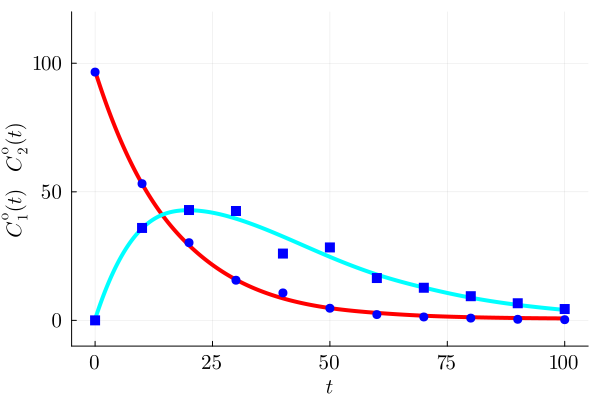

In [114]:
d0=data[1,:];
d1 = [-θ4[1]*C1f[i] for i in eachindex(tf)];
Coeff1 = vcat(w[1]*C1_sp,w[2]*C1_1spf) \ vcat(w[1]*d0,w[2]*d1);

d0=data[2,:];
d1 = [+θ4[1]*C1f[i]-θ4[2]*C2f[i] for i in eachindex(tf)];
Coeff2 = vcat(w[1]*C2_sp, w[2]*C2_1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,C1f,lw=4,lc=:red,label=false)
p4 = plot!(tf,C2f,lw=4,lc=:aqua,label=false)
p4=scatter!(t,data[1,:],mc=:blue,msc=:blue,ms=5,label=false)
p4=scatter!(t,data[2,:],mc=:blue,msc=:blue,ms=5,marker=:square,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C_1^{\textrm{o}}(t) \quad C_2^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

In [115]:
C1= C1_sp*Coeff1; C1f = C1_spf*Coeff1; dC1f = C1_1spf*Coeff1;
C2= C2_sp*Coeff2; C2f = C2_spf*Coeff2; dC2f = C2_1spf*Coeff2;

ℓd=0
data_dists1=[LogNormal(0,θ4[3]) for _ in t];
data_dists2=[LogNormal(0,θ4[3]) for _ in t];

ℓd += sum(
    loglikelihood(data_dists1[i], data[1,i] / C1[i])
    for i in 1:length(data_dists1)
    if data[1,i] > 0 && C1[i] > 0
)  

ℓd+= sum(
    loglikelihood(data_dists2[i], data[2,i] /  C2[i])
    for i in 1:length(data_dists2)
    if data[2,i] > 0 && C2[i] > 0
)

ℓm =0;
ℓm = sum((dC1f.+ θ4[1].*C1f).^2)/ length(tf) + sum((dC2f .- θ4[1].*C1f .+θ4[2].*C2f).^2)/ length(tf) 

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance -2.308306872493091
Model distance 0.0049424983176662145


Iteration 5

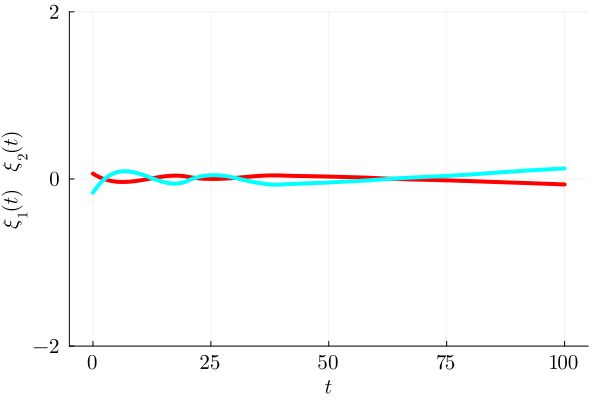

In [116]:
funopt5(a) = loglhood(data,C1,C1f,dC1f,C2,C2f,dC2f,t,tf,w,a) #Here setting the weight to one
(θ5,fopt)=Optimise(funopt5,θG,lb,ub) #Call to NLopt 

a1 =  plot(tf,dC1f .+ θ5[1].*C1f,lw=4,color=:red,legend=false)
a1 = plot!(tf,dC2f .- θ5[1].*C1f.+ θ5[2].*C2f, lw=4,color=:aqua,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi_1(t) \quad \xi_2(t)",color=:red,xlims=(t[1]-5,t[end]+5),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14,ylims=[-2,2],yticks = ([-2, 0, 2],[L"-2", L"0", L"2"]))

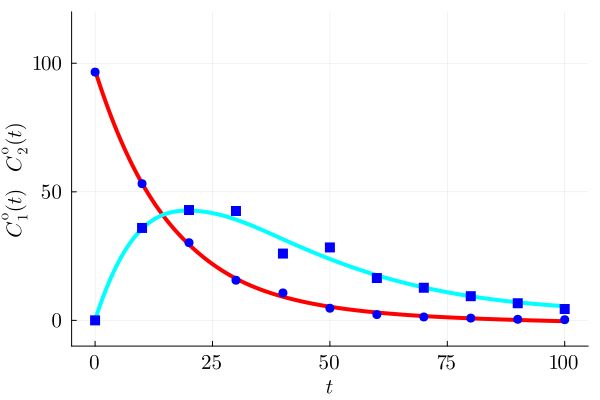

In [117]:
d0=data[1,:];
d1 = [-θ5[1]*C1f[i] for i in eachindex(tf)];
Coeff1 = vcat(w[1]*C1_sp,w[2]*C1_1spf) \ vcat(w[1]*d0,w[2]*d1);

d0=data[2,:];
d1 = [+θ5[1]*C1f[i]-θ5[2]*C2f[i] for i in eachindex(tf)];
Coeff2 = vcat(w[1]*C2_sp, w[2]*C2_1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,C1f,lw=4,lc=:red,label=false)
p4 = plot!(tf,C2f,lw=4,lc=:aqua,label=false)
p4=scatter!(t,data[1,:],mc=:blue,msc=:blue,ms=5,label=false)
p4=scatter!(t,data[2,:],mc=:blue,msc=:blue,ms=5,marker=:square,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C_1^{\textrm{o}}(t) \quad C_2^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

In [118]:
C1= C1_sp*Coeff1; C1f = C1_spf*Coeff1; dC1f = C1_1spf*Coeff1;
C2= C2_sp*Coeff2; C2f = C2_spf*Coeff2; dC2f = C2_1spf*Coeff2;

ℓd=0
data_dists1=[LogNormal(0,θ5[3]) for _ in t];
data_dists2=[LogNormal(0,θ5[3]) for _ in t];

ℓd += sum(
    loglikelihood(data_dists1[i], data[1,i] / C1[i])
    for i in 1:length(data_dists1)
    if data[1,i] > 0 && C1[i] > 0
)  

ℓd+= sum(
    loglikelihood(data_dists2[i], data[2,i] /  C2[i])
    for i in 1:length(data_dists2)
    if data[2,i] > 0 && C2[i] > 0
)

ℓm =0;
ℓm = sum((dC1f.+ θ5[1].*C1f).^2)/ length(tf) + sum((dC2f .- θ5[1].*C1f .+θ5[2].*C2f).^2)/ length(tf) 

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance -17.279555339476058
Model distance 0.0035580852123417903


Iteration 6

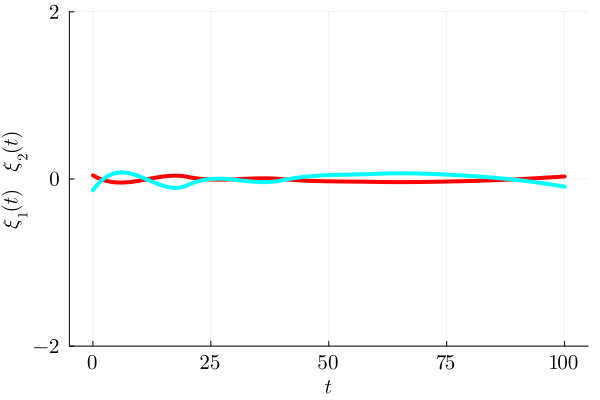

In [119]:
funopt6(a) = loglhood(data,C1,C1f,dC1f,C2,C2f,dC2f,t,tf,w,a) #Here setting the weight to one
(θ6,fopt)=Optimise(funopt6,θG,lb,ub) #Call to NLopt 

a1 =  plot(tf,dC1f .+ θ6[1].*C1f,lw=4,color=:red,legend=false)
a1 = plot!(tf,dC2f .- θ6[1].*C1f.+ θ6[2].*C2f, lw=4,color=:aqua,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi_1(t) \quad \xi_2(t)",color=:red,xlims=(t[1]-5,t[end]+5),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14,ylims=[-2,2],yticks = ([-2, 0, 2],[L"-2", L"0", L"2"]))

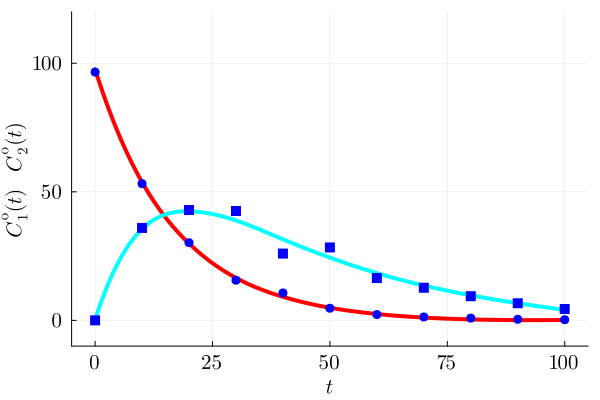

In [120]:
d0=data[1,:];
d1 = [-θ6[1]*C1f[i] for i in eachindex(tf)];
Coeff1 = vcat(w[1]*C1_sp,w[2]*C1_1spf) \ vcat(w[1]*d0,w[2]*d1);

d0=data[2,:];
d1 = [+θ6[1]*C1f[i]-θ6[2]*C2f[i] for i in eachindex(tf)];
Coeff2 = vcat(w[1]*C2_sp, w[2]*C2_1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,C1f,lw=4,lc=:red,label=false)
p4 = plot!(tf,C2f,lw=4,lc=:aqua,label=false)
p4=scatter!(t,data[1,:],mc=:blue,msc=:blue,ms=5,label=false)
p4=scatter!(t,data[2,:],mc=:blue,msc=:blue,ms=5,marker=:square,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C_1^{\textrm{o}}(t) \quad C_2^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

In [121]:
C1= C1_sp*Coeff1; C1f = C1_spf*Coeff1; dC1f = C1_1spf*Coeff1;
C2= C2_sp*Coeff2; C2f = C2_spf*Coeff2; dC2f = C2_1spf*Coeff2;

ℓd=0
data_dists1=[LogNormal(0,θ6[3]) for _ in t];
data_dists2=[LogNormal(0,θ6[3]) for _ in t];

ℓd += sum(
    loglikelihood(data_dists1[i], data[1,i] / C1[i])
    for i in 1:length(data_dists1)
    if data[1,i] > 0 && C1[i] > 0
)  

ℓd+= sum(
    loglikelihood(data_dists2[i], data[2,i] /  C2[i])
    for i in 1:length(data_dists2)
    if data[2,i] > 0 && C2[i] > 0
)

ℓm =0;
ℓm = sum((dC1f.+ θ6[1].*C1f).^2)/ length(tf) + sum((dC2f .- θ6[1].*C1f .+θ6[2].*C2f).^2)/ length(tf) 

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance -5.3506759878748875
Model distance 0.005176749468298783


Iteration 7

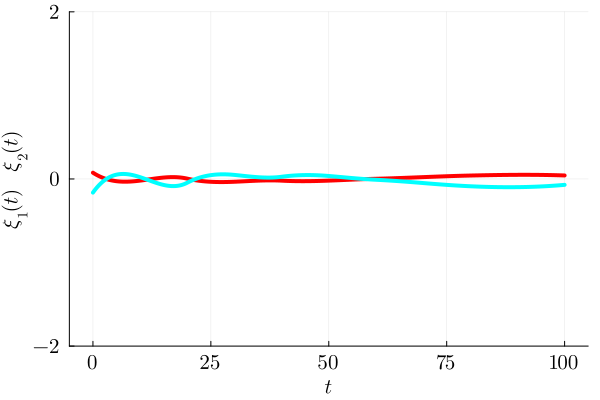

In [122]:
funopt7(a) = loglhood(data,C1,C1f,dC1f,C2,C2f,dC2f,t,tf,w,a) #Here setting the weight to one
(θ7,fopt)=Optimise(funopt7,θG,lb,ub) #Call to NLopt 

a1 =  plot(tf,dC1f .+ θ7[1].*C1f,lw=4,color=:red,legend=false)
a1 = plot!(tf,dC2f .- θ7[1].*C1f.+ θ7[2].*C2f, lw=4,color=:aqua,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi_1(t) \quad \xi_2(t)",color=:red,xlims=(t[1]-5,t[end]+5),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14,ylims=[-2,2],yticks = ([-2, 0, 2],[L"-2", L"0", L"2"]))

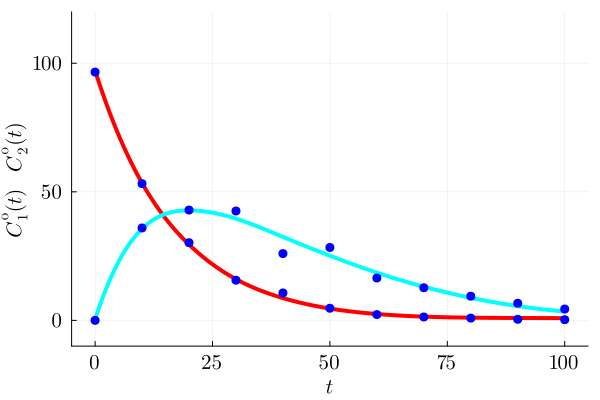

In [123]:
d0=data[1,:];
d1 = [-θ7[1]*C1f[i] for i in eachindex(tf)];
Coeff1 = vcat(w[1]*C1_sp,w[2]*C1_1spf) \ vcat(w[1]*d0,w[2]*d1);

d0=data[2,:];
d1 = [+θ7[1]*C1f[i]-θ7[2]*C2f[i] for i in eachindex(tf)];
Coeff2 = vcat(w[1]*C2_sp, w[2]*C2_1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,C1f,lw=4,lc=:red,label=false)
p4 = plot!(tf,C2f,lw=4,lc=:aqua,label=false)
p4=scatter!(t,data[1,:],mc=:blue,msc=:blue,ms=5,label=false)
p4=scatter!(t,data[2,:],mc=:blue,msc=:blue,ms=5,lmarker=:sqare,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C_1^{\textrm{o}}(t) \quad C_2^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

In [124]:
C1= C1_sp*Coeff1; C1f = C1_spf*Coeff1; dC1f = C1_1spf*Coeff1;
C2= C2_sp*Coeff2; C2f = C2_spf*Coeff2; dC2f = C2_1spf*Coeff2;

ℓd=0
data_dists1=[LogNormal(0,θ7[3]) for _ in t];
data_dists2=[LogNormal(0,θ7[3]) for _ in t];

ℓd += sum(
    loglikelihood(data_dists1[i], data[1,i] / C1[i])
    for i in 1:length(data_dists1)
    if data[1,i] > 0 && C1[i] > 0
)  

ℓd+= sum(
    loglikelihood(data_dists2[i], data[2,i] /  C2[i])
    for i in 1:length(data_dists2)
    if data[2,i] > 0 && C2[i] > 0
)

ℓm =0;
ℓm = sum((dC1f.+ θ7[1].*C1f).^2)/ length(tf) + sum((dC2f .- θ7[1].*C1f .+θ7[2].*C2f).^2)/ length(tf) 

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance -7.518638734645117
Model distance 0.0037596208116766924


Iteration 8

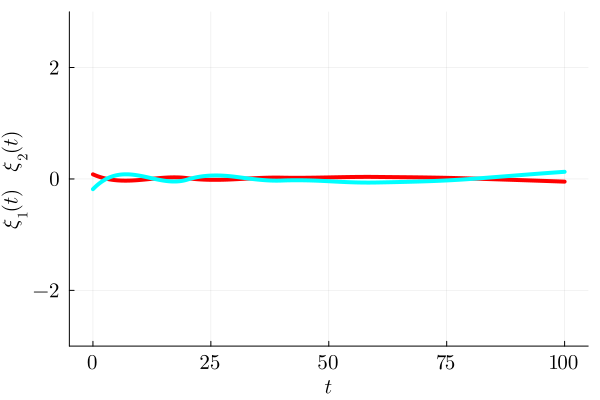

In [125]:
funopt8(a) = loglhood(data,C1,C1f,dC1f,C2,C2f,dC2f,t,tf,w,a) #Here setting the weight to one
(θ8,fopt)=Optimise(funopt8,θG,lb,ub) #Call to NLopt 

a1 =  plot(tf,dC1f .+ θ8[1].*C1f,lw=4,color=:red,legend=false)
a1 = plot!(tf,dC2f .- θ8[1].*C1f.+ θ8[2].*C2f, lw=4,color=:aqua,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi_1(t) \quad \xi_2(t)",color=:red,xlims=(t[1]-5,t[end]+5),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14,ylims=[-3,3],yticks = ([-2, 0, 2],[L"-2", L"0", L"2"]))

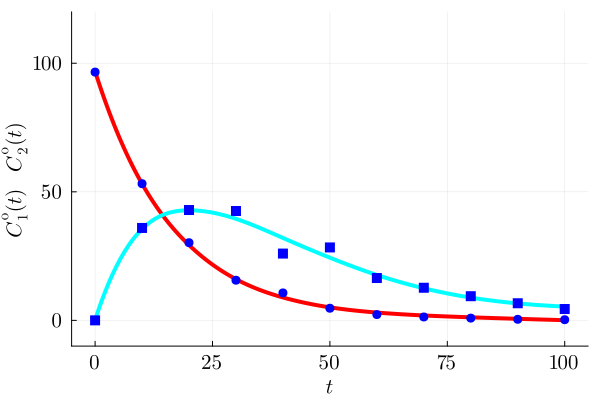

In [126]:
d0=data[1,:];
d1 = [-θ8[1]*C1f[i] for i in eachindex(tf)];
Coeff1 = vcat(w[1]*C1_sp,w[2]*C1_1spf) \ vcat(w[1]*d0,w[2]*d1);

d0=data[2,:];
d1 = [+θ8[1]*C1f[i]-θ8[2]*C2f[i] for i in eachindex(tf)];
Coeff2 = vcat(w[1]*C2_sp, w[2]*C2_1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,C1f,lw=4,lc=:red,label=false)
p4 = plot!(tf,C2f,lw=4,lc=:aqua,label=false)
p4=scatter!(t,data[1,:],mc=:blue,msc=:blue,ms=5,label=false)
p4=scatter!(t,data[2,:],mc=:blue,msc=:blue,ms=5,marker=:square,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C_1^{\textrm{o}}(t) \quad C_2^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

In [127]:
C1= C1_sp*Coeff1; C1f = C1_spf*Coeff1; dC1f = C1_1spf*Coeff1;
C2= C2_sp*Coeff2; C2f = C2_spf*Coeff2; dC2f = C2_1spf*Coeff2;

ℓd=0
data_dists1=[LogNormal(0,θ8[3]) for _ in t];
data_dists2=[LogNormal(0,θ8[3]) for _ in t];

ℓd += sum(
    loglikelihood(data_dists1[i], data[1,i] / C1[i])
    for i in 1:length(data_dists1)
    if data[1,i] > 0 && C1[i] > 0
)  

ℓd+= sum(
    loglikelihood(data_dists2[i], data[2,i] /  C2[i])
    for i in 1:length(data_dists2)
    if data[2,i] > 0 && C2[i] > 0
)

ℓm =0;
ℓm = sum((dC1f.+ θ8[1].*C1f).^2)/ length(tf) + sum((dC2f .- θ8[1].*C1f .+θ8[2].*C2f).^2)/ length(tf) 

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 0.3017829353696231
Model distance 0.00442022156967488


Iteration 9

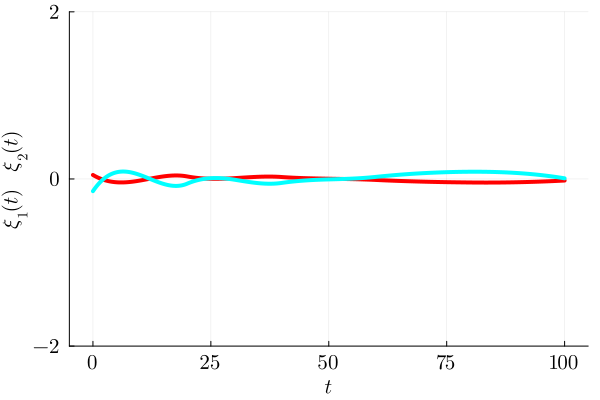

In [128]:
funopt9(a) = loglhood(data,C1,C1f,dC1f,C2,C2f,dC2f,t,tf,w,a) #Here setting the weight to one
(θ9,fopt)=Optimise(funopt9,θG,lb,ub) #Call to NLopt 

a1 =  plot(tf,dC1f .+ θ9[1].*C1f,lw=4,color=:red,legend=false)
a1 = plot!(tf,dC2f .- θ9[1].*C1f.+ θ9[2].*C2f, lw=4,color=:aqua,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi_1(t) \quad \xi_2(t)",color=:red,xlims=(t[1]-5,t[end]+5),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14,ylims=[-2,2],yticks = ([-4, -2, 0, 2,4],[L"-4", L"-2", L"0", L"2", L"4"]))

In [133]:
d0=data[1,:];
d1 = [-θ9[1]*C1f[i] for i in eachindex(tf)];
Coeff1 = vcat(w[1]*C1_sp,w[2]*C1_1spf) \ vcat(w[1]*d0,w[2]*d1);

d0=data[2,:];
d1 = [+θ9[1]*C1f[i]-θ9[2]*C2f[i] for i in eachindex(tf)];
Coeff2 = vcat(w[1]*C2_sp, w[2]*C2_1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,C1f,lw=4,lc=:red,label=false)
p4 = plot!(tf,C2f,lw=4,lc=:aqua,label=false)
p4=scatter!(t,data[1,:],mc=:blue,msc=:blue,ms=5,label=false)
p4=scatter!(t,data[2,:],mc=:blue,msc=:blue,ms=5,marker=:square,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C_1^{\textrm{o}}(t) \quad C_2^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
savefig("f5c.svg")

"C:\\Users\\simpsom3\\Dropbox\\Generalised Profiling\\Notebooks\\f5c.svg"

In [130]:
C1= C1_sp*Coeff1; C1f = C1_spf*Coeff1; dC1f = C1_1spf*Coeff1;
C2= C2_sp*Coeff2; C2f = C2_spf*Coeff2; dC2f = C2_1spf*Coeff2;

ℓd=0
data_dists1=[LogNormal(0,θ9[3]) for _ in t];
data_dists2=[LogNormal(0,θ9[3]) for _ in t];

ℓd += sum(
    loglikelihood(data_dists1[i], data[1,i] / C1[i])
    for i in 1:length(data_dists1)
    if data[1,i] > 0 && C1[i] > 0
)  

ℓd+= sum(
    loglikelihood(data_dists2[i], data[2,i] /  C2[i])
    for i in 1:length(data_dists2)
    if data[2,i] > 0 && C2[i] > 0
)

ℓm =0;
ℓm = sum((dC1f.+ θ9[1].*C1f).^2)/ length(tf) + sum((dC2f .- θ9[1].*C1f .+θ9[2].*C2f).^2)/ length(tf) 

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance -1.7036154966066706
Model distance 0.0042682785904562875


In [132]:
funopt10(a) = loglhood(data,C1,C1f,dC1f,C2,C2f,dC2f,t,tf,w,a) #Here setting the weight to one
(θ10,fopt)=Optimise(funopt10,θG,lb,ub) #Call to NLopt 

a1 =  plot(tf,dC1f .+ θ10[1].*C1f,lw=4,color=:red,legend=false)
a1 = plot!(tf,dC2f .- θ10[1].*C1f.+ θ10[2].*C2f, lw=4,color=:aqua,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi_1(t) \quad \xi_2(t)",color=:red,xlims=(t[1]-5,t[end]+5),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14,ylims=[-2,2],yticks = ([-4, -2, 0, 2,4],[L"-4", L"-2", L"0", L"2", L"4"]))
savefig("f5d.svg")

"C:\\Users\\simpsom3\\Dropbox\\Generalised Profiling\\Notebooks\\f5d.svg"

In [92]:
C1f[1]

97.28084726076517

In [93]:
C2f[1]

0.1697082786613395

In [94]:
C1e(t) =C1f[1]*exp(-θ10[1]*t);
C2e(t) = C1f[1]*exp(-θ10[1]*t)*θ10[1]/(θ10[2]-θ10[1])+(C2f[1]-θ10[1]*C1f[1]/(θ10[2]-θ10[1]))*exp(-θ10[2]*t);

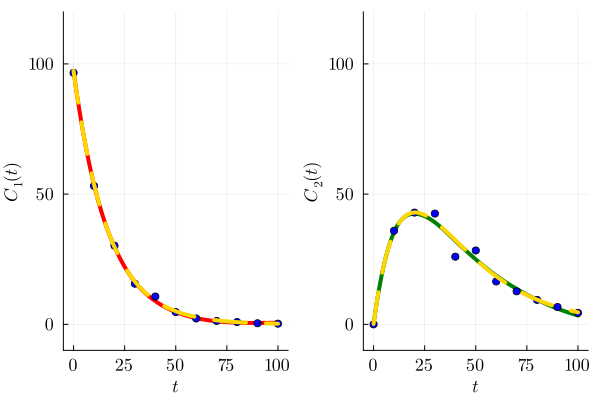

In [95]:
p4 = plot(tf,C1_spf*Coeff1; lw=4,lc=:red,label=false)
p4=scatter!(t,data[1,:],mc=:blue,msc=:match,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C_1(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=12, yguidefontsize=12,xtickfontsize=12, ytickfontsize=12)
p4=plot!(C1e,0,Tend,lw=4,lc=:gold,ls=:dash,legend=false)

p5 = plot(tf,C2_spf*Coeff2; lw=4,lc=:green,label=false)
p5=scatter!(t,data[2,:],mc=:blue,msc=:match,label=false)
p5=plot!(xlabel=L"t",ylabel=L"C_2(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p5=plot!(xguidefontsize=12, yguidefontsize=12,xtickfontsize=12, ytickfontsize=12)
p5=plot!(C2e,0,Tend,lw=4,lc=:gold,ls=:dash,legend=false)

p6=plot(p4,p5,layout=(1,2))
display(p6)

In [96]:
θ1

3-element Vector{Float64}:
 0.06050405614770056
 0.04146319200735299
 0.01

In [97]:
θ6

3-element Vector{Float64}:
 0.059273260496437094
 0.040859455829318665
 0.3849159552331291

In [98]:
θ10

3-element Vector{Float64}:
 0.059255234514734634
 0.040255559767328905
 0.23788787188831048